In [1]:
import copy
import joblib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import sys
import warnings
import nibabel as nib
from collections.abc import Iterable

from nilearn import plotting
from nilearn.image import get_data, math_img, new_img_like, threshold_img
from nilearn.regions import connected_regions
from scipy.ndimage import label
# Extend sys.path to import project modules
sys.path.append('/home/reabt/experiments/ncc/MRI/code/')
# from utils.load_cfg import load_config_instance
from utils.load_cfg import load_MRI_config_instance
from utils.compile import compile_SL_rdms_files
from utils.subj import * 


# Functions

In [185]:
def RDMcolormapObject(direction=1):
    cs = ['blue', 'turquoise', 'gray', 'red', 'yellow'] if direction else ['yellow', 'red', 'gray', 'turquoise', 'blue']
    return mcolors.LinearSegmentedColormap.from_list("", cs)

def plot_brainSlices(plot_img, cmap, title='', threshold = 1e-6, n_slices = 8, figsize=None, ax = None, fig = None):
    if figsize == None:
        figsize=(12, 3)
    if fig == None:
        fig = plt.figure(figsize=figsize)

    plotting.plot_stat_map(
        plot_img, 
        colorbar=True,
        threshold=threshold,
        cut_coords=8,
        display_mode='z', 
        draw_cross=False, 
        figure=fig,
        # title=title, 
        cmap=cmap,
        axes = ax,
        black_bg=False, 
        annotate=False
    )
    # fig.suptitle(title, fontsize=10, backgroundcolor='black', color='white', position=(0,0))
    plt.show()

cmap = RDMcolormapObject()


def plot_all(all_subjects, config_class_name, thres= 95):

    models = ["sensory", "suprasensory"]

    all_images = {}
    for m, model in enumerate(models):

        RDM_brain_list = []
        for n, subjectID in enumerate(all_subjects):
            cfg = load_MRI_config_instance(config_class_name, subjectID)
            cfg.configure_paths()
            outFiles = cfg.get_outFile_names()
            if config_class_name == 'MRIconfig_C5':
                RDM_brain_file = f'/home/reabt/experiments/ncc/MRI/data/rsa/MRIconfig_C5/spearman/{subjectID}/fullBrain_SL_C5_SM1C_24Cond_crossnobis_spearman_r5_thr1_{model}_RDM_brain.pkl'
            elif config_class_name == 'MRIconfig_C2':
                RDM_brain_file = f'/home/reabt/experiments/ncc/MRI/data/rsa/MRIconfig_C2/{subjectID}/fullBrain_SL_C2_SM1C_24Cond_crossnobis_corr_cov_r2_thr1_{model}_RDM_brain.pkl'
            # RDM_brain = joblib.load(outFiles['RDM_brain_fullBrain'])
            RDM_brain = joblib.load(RDM_brain_file)
        
            mask = nib.load(cfg.get_mask_file())
            RDM_brain_nan = copy.deepcopy(RDM_brain)
            RDM_brain_nan[RDM_brain_nan == 0] = np.nan
            threshold = np.nanpercentile(RDM_brain_nan, thres)

            #%% 4) --- plot mean over subjects but omit zeros (NaN)
            subj_img = new_img_like(mask, RDM_brain)

            thres_img = threshold_img(subj_img, 
                                            threshold=threshold, 
                                            copy=True, 
                                            copy_header=True)
            RDM_brain_list.append(thres_img)
            # title=f'{model} results subject: ' + subjectID
            # plot_brainSlices(mean_nan_img, cmap = 'PuRd', title=title, threshold = threshold, n_slices=10, figsize=(20,len(all_subjects)), fig=fig, ax=axes[n,m])
            
        all_images[model]=RDM_brain_list

    fig, axes = plt.subplots(ncols=2, nrows=len(all_subjects), figsize=(20,1.5*len(all_subjects))) #, subplot_kw={'projection': 'polar'})    #  subplot_kw={'projection': '3d'})
    for m, model in enumerate(models):
        for n, img in enumerate(all_images[model]):
            plotting.plot_stat_map(
                img, 
                colorbar=False,
                cut_coords=8,
                display_mode='z', 
                draw_cross=False, 
                figure=fig,
                cmap='PuRd',
                axes = axes[n, m],
                black_bg=False, 
                annotate=False
            )
            ax = axes[n, m]
            ax.set_title(all_subjects[n], fontsize=7, backgroundcolor='black', color='white', y=0.5, position=(0,0))

    for ax, col in zip(axes[0], ["sensory", "suprasensory"]):
        ax.annotate(col, xy=(0.5, 1.2), xytext=(0, 0), xycoords='axes fraction', textcoords='offset points', size='large', ha='center', va='center')

    fig.subplots_adjust(
        # hspace=0, 
        # top=0.8, 
        bottom=0.1, 
        left=0.1, 
        wspace=0.1
        )
    plt.show  

def plot_accumulated_thres(all_subjects, config_class_name, model, thres= 95, plotList = [1], save = False):
    cfg = load_MRI_config_instance(config_class_name, all_subjects[0])
    cfg.configure_paths()
    mask = nib.load(cfg.get_mask_file())

    sum_threshold_mask = np.zeros(mask.get_fdata().shape)

    for subjectID in all_subjects:

        cfg = load_MRI_config_instance(config_class_name, subjectID)
        cfg.configure_paths()
        outFiles = cfg.get_outFile_names()
        if config_class_name == 'MRIconfig_C5':
            RDM_brain_file = f'/home/reabt/experiments/ncc/MRI/data/rsa/MRIconfig_C5/spearman/{subjectID}/fullBrain_SL_C5_SM1C_24Cond_crossnobis_spearman_r5_thr1_{model}_RDM_brain.pkl'
        elif config_class_name == 'MRIconfig_C2':
            RDM_brain_file = f'/home/reabt/experiments/ncc/MRI/data/rsa/MRIconfig_C2/{subjectID}/fullBrain_SL_C2_SM1C_24Cond_crossnobis_corr_cov_r2_thr1_{model}_RDM_brain.pkl'
        # RDM_brain = joblib.load(outFiles['RDM_brain_fullBrain'])
        RDM_brain = joblib.load(RDM_brain_file)
        mask = nib.load(cfg.get_mask_file())
        RDM_brain_nan = copy.deepcopy(RDM_brain)
        RDM_brain_nan[RDM_brain_nan == 0] = np.nan

        threshold = np.nanpercentile(RDM_brain_nan, thres)
        # print(f"Threshold: {threshold}")
        mean_nan_img = new_img_like(mask, RDM_brain)
        threshold_value_img = threshold_img(mean_nan_img, 
                                            threshold=threshold, 
                                            copy=True, 
                                            copy_header=True
        )

        threshold_mask = np.zeros(threshold_value_img.get_fdata().shape)
        threshold_mask[threshold_value_img.get_fdata() > 0] = 1

        sum_threshold_mask += threshold_mask

    sum_threshold_mask_img = new_img_like(mask, sum_threshold_mask)
    cfg
    if save:
        outDir = '/home/reabt/experiments/ncc/MRI/data/rsa'
        nii_filename = os.path.join(outDir, f'sum_threshold_mask_img__{model}__{config_class_name}__thres_{thres}__{len(all_subjects)}_subj.nii')
        nib.save(sum_threshold_mask_img, nii_filename)


    vmin = 0
    vmax = len(all_subjects)

    # --- for plotting:
    # Define your discrete color levels
    levels = np.arange(vmin, vmax + 2)  # one more than vmax for bins
    n_colors = len(levels) - 1

    # Create a discrete colormap using viridis
    base_cmap = plt.get_cmap('viridis')
    colors = base_cmap(np.linspace(0, 1, n_colors))
    cmap = ListedColormap(colors)

    # Create a normalization object to define the boundaries
    norm = BoundaryNorm(boundaries=levels, ncolors=n_colors)

    title = f'{model} (config {config_class_name[-2 :]}): sum of threshold mask images over {len(all_subjects)} subjects with thres = {thres}'
    # Plot with custom colormap and norm
    if 1 in plotList:
        display = plotting.plot_stat_map(
            sum_threshold_mask_img,
            display_mode="z",
            cut_coords=15,
            title=title,
            cmap=cmap,
            colorbar=True,
            vmin=vmin,
            vmax=vmax,
        )

        cbar = display._cbar
        cbar.set_ticks(np.arange(vmin, vmax + 1))
        cbar.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
        cbar.ax.tick_params(labelsize=12)

    if 2 in plotList:
        display = plotting.plot_stat_map(
            sum_threshold_mask_img,
            display_mode="ortho",
            title=title,
            cbar_tick_format = "%i",
            colorbar=True,
            vmin=vmin,
            vmax=vmax,
            cmap = 'viridis'
        )

        cbar = display._cbar
        cbar.set_ticks(np.arange(vmin, vmax + 1))
        cbar.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
        cbar.ax.tick_params(labelsize=12)

    if 3 in plotList:
        display = plotting.plot_glass_brain(
            sum_threshold_mask_img,
            display_mode="ortho",
            title=title,
            cbar_tick_format = "%i",
            colorbar=True,
            vmin=vmin,
            vmax=vmax,
            cmap = 'viridis'
        )

        cbar = display._cbar
        cbar.set_ticks(np.arange(vmin, vmax + 1))
        cbar.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
        cbar.ax.tick_params(labelsize=12)


def plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 95, plottype = 1):
    # load data
    if not isinstance(plottype, Iterable):
        plottype = [plottype]

    allModels = ALL_MODELS
    
    for model in allModels:

        RDM_brain_list = []
        for subjectID in all_subjects:
            cfg = load_MRI_config_instance(config_class_name, subjectID)
            cfg.modelType = model  
            outFiles = cfg.get_outFile_names()

            RDM_brain = joblib.load(outFiles['RDM_brain_fullBrain'])

            RDM_brain_list.append(RDM_brain)
        
        mask = nib.load(cfg.get_mask_file())
        RDM_brain_all = np.stack(RDM_brain_list, axis=-1)

        zero_count_3d = np.sum(RDM_brain_all == 0, axis=-1)
        no_zeros_bool = zero_count_3d == 0


        RDM_brain_mean = np.mean(RDM_brain_all, axis=-1)
        mean_mask_img = nib.Nifti1Image(RDM_brain_mean.astype(np.int16), mask.affine)
        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # compute the mean again but set zeros to NaNs first and omit them
        RDM_brain_all_nan = copy.deepcopy(RDM_brain_all)
        RDM_brain_all_nan[RDM_brain_all_nan == 0] = np.nan

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            RDM_brain_mean_nan = np.nanmean(RDM_brain_all_nan, axis=-1)
        try:
            if thres_type == 'percentage':
                threshold = np.nanpercentile(RDM_brain_mean_nan, thres)
                thres_string = str(thres)
            elif thres_type == 'fixed':
                threshold = thres
                thres_string = f'fix{str(thres).replace('.', '_')}'
        except:
            print('More info needed: Do you want to set a fixed threshold or compute it from the data?')
        
        RDM_brain_nan_mean_noZeros = np.zeros(RDM_brain_mean_nan.shape)
        RDM_brain_nan_mean_noZeros[no_zeros_bool] = RDM_brain_mean_nan[no_zeros_bool]

        if 1 in plottype:
            mean_nan_img = new_img_like(mask, RDM_brain_mean_nan)
            plot_brainSlices(mean_nan_img, 
                             cmap = 'inferno', 
                             title=f'{cfg.RDMmethod} {cfg.modelType} (config {config_class_name[-2 :]}): mean results over {RDM_brain_all.shape[3]} subjects without zeros (NaN)', 
                             threshold = threshold)
        if 2 in plottype:
            mean_nan_noZeros_img = new_img_like(mask, RDM_brain_nan_mean_noZeros)

            plot_brainSlices(mean_nan_noZeros_img, 
                             cmap = 'inferno', 
                             title=f'{cfg.RDMmethod} {cfg.modelType} (config {config_class_name[-2 :]}): SL-radius = {cfg.SLradius}, mean results over {RDM_brain_all.shape[3]} subjects with no-zeros mask, threshold: {thres_string} %', 
                             threshold = threshold)

# show single subjects

Removed bad subject: 19970218crpo

all MRI subjects: ['20010917rswg', '19960630cahi', '19970302urmr', '19840930bigs', '20040627vrrj', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19921205crfi', '19991211mrbn', '19910823ssld', '19910703eigl']


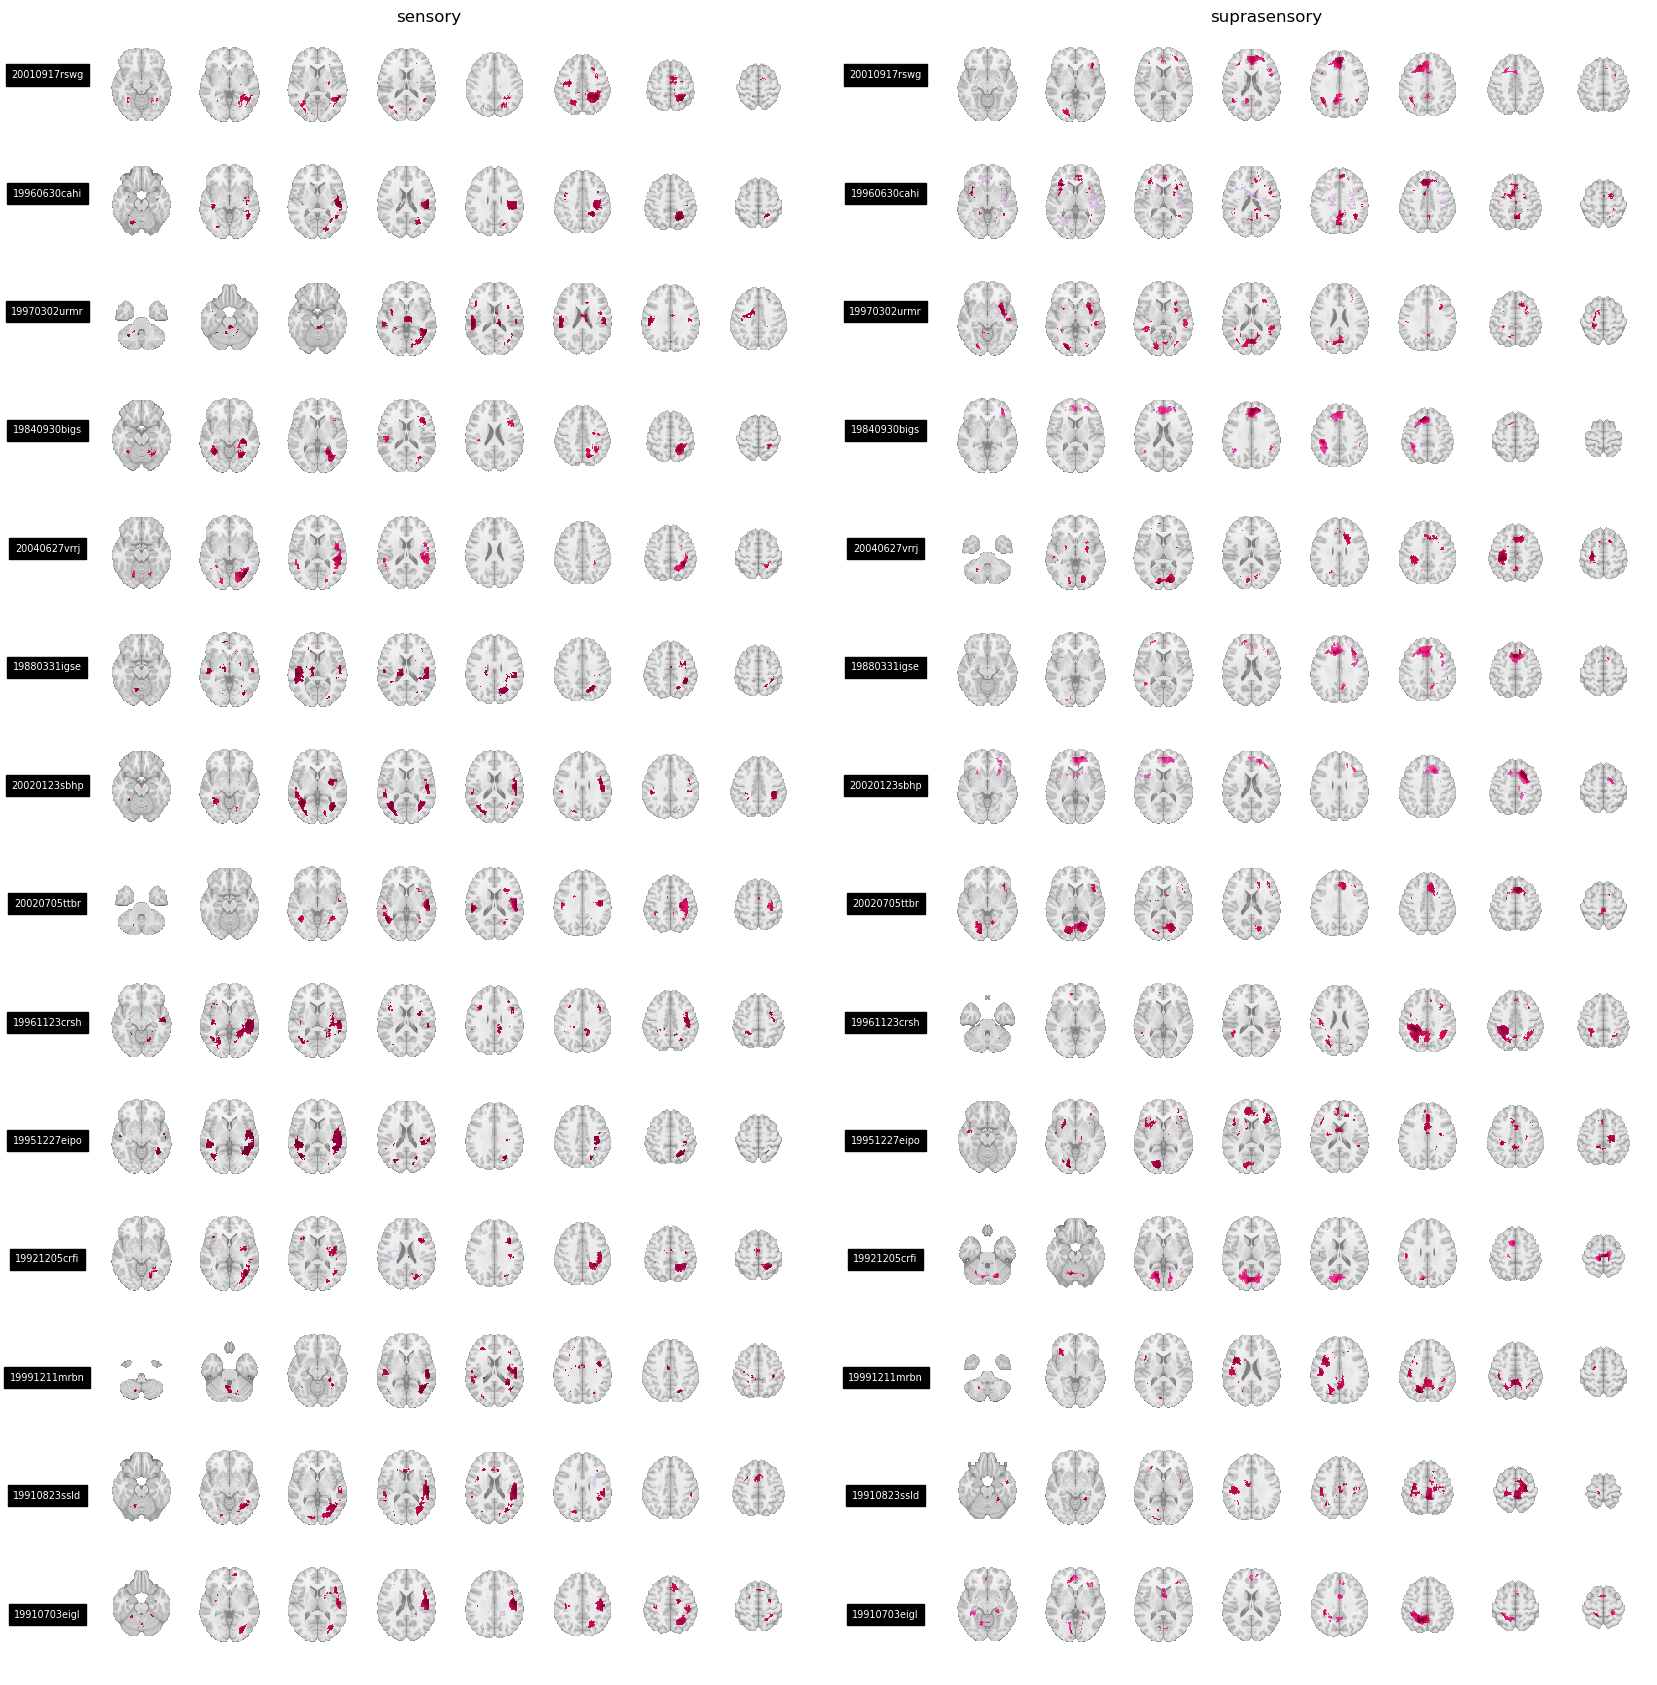

In [186]:
MRI_subjects = get_MRI_subjects()
all_subjects = [subj for subj in MRI_subjects if '19970218crpo' not in subj]
config_class_name = 'MRIconfig_C5'
plot_all(all_subjects, config_class_name, thres=95)

Removed bad subject: 19970218crpo

all MRI subjects: ['20010917rswg', '19960630cahi', '19970302urmr', '19840930bigs', '20040627vrrj', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19921205crfi', '19991211mrbn', '19910823ssld', '19910703eigl']


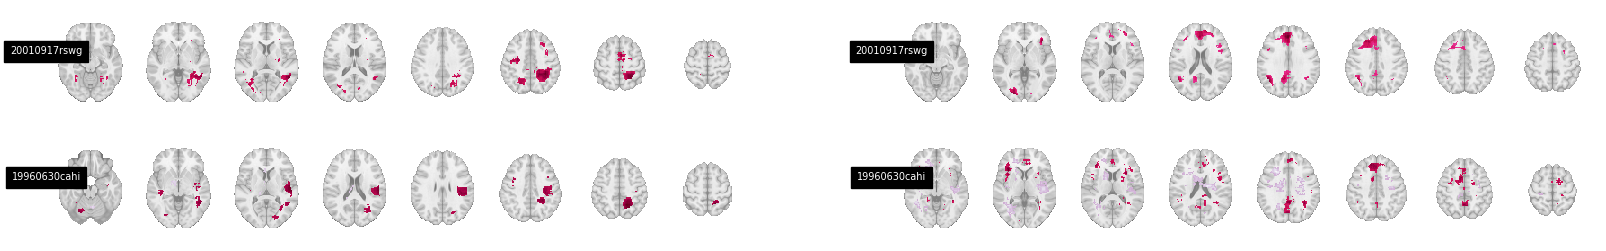

In [62]:
MRI_subjects = get_MRI_subjects()
all_subjects = [subj for subj in MRI_subjects if '19970218crpo' not in subj]
config_class_name = 'MRIconfig_C5'
model = 'sensory'
axes, fig = plot_all(all_subjects[0:2], config_class_name, thres=95)
# plot_all(all_subjects, config_class_name, thres=95)

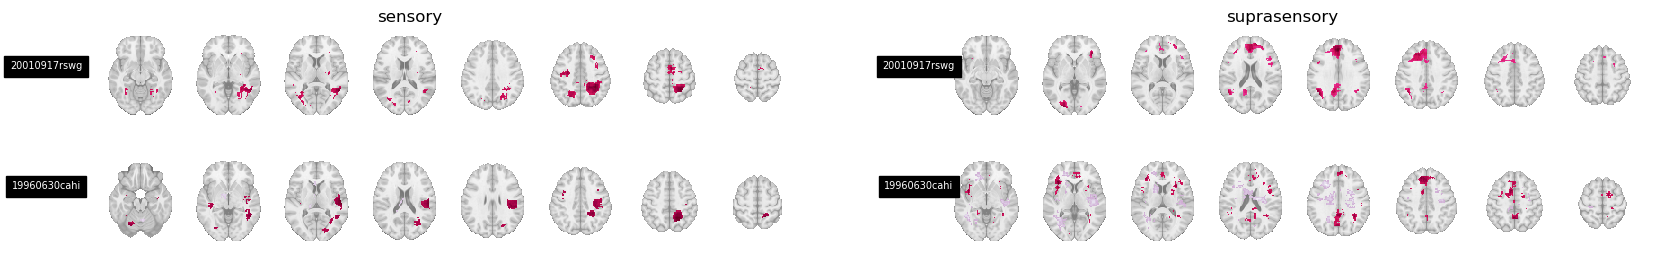

In [120]:
from copy import deepcopy
pad=0
axes1 = deepcopy(axes)

for ax, col in zip(axes1[0], ["sensory", "suprasensory"]):
    ax.annotate(col, xy=(0.5, 1.5), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='center')

    # ax.set_ybound(-2)

# for row in np.arange(0, axes1.shape[0]):
#     for col in np.arange(0, axes1.shape[1]):
#         ax = axes1[row,col]
#         box = ax.get_position()
#         # ax.set_position([[box.x0, box.y0], [box.x1, box.y1]])

fig2 = axes1[0,0].figure
# fig2.subplots_adjust(top=0.85, right=8)
fig2.subplots_adjust(hspace=1, top=0.8, bottom=0.2, left=0.1)
fig2


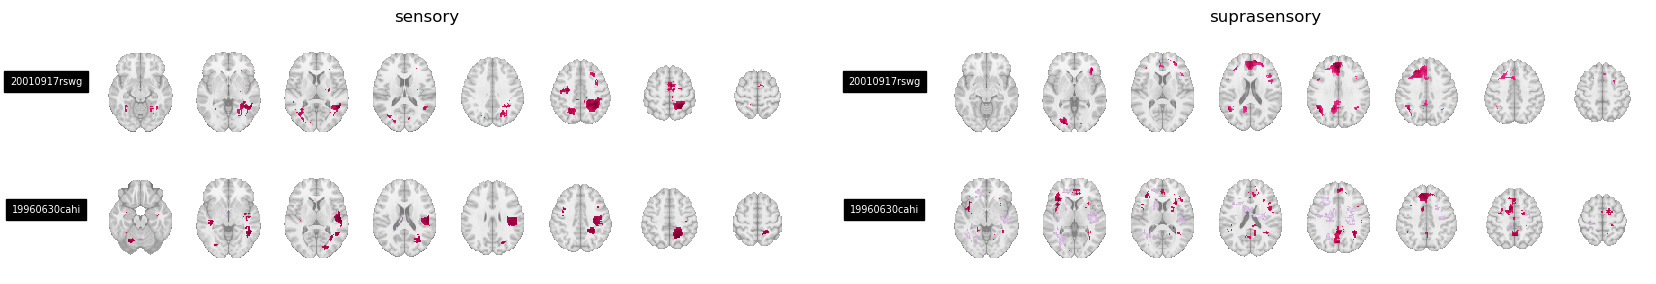

In [173]:

pad=0
axes1 = deepcopy(axes)

for ax, col in zip(axes1[0], ["sensory", "suprasensory"]):
    ax.annotate(col, xy=(0.5, 1.2), xytext=(0, 1),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='center')

fig2 = axes1[0,0].figure
fig2.subplots_adjust(
    # hspace=0, 
    # top=0.8, 
    bottom=0.1, 
    left=0.1, 
    wspace=0.1
    )
fig2


hi
hi


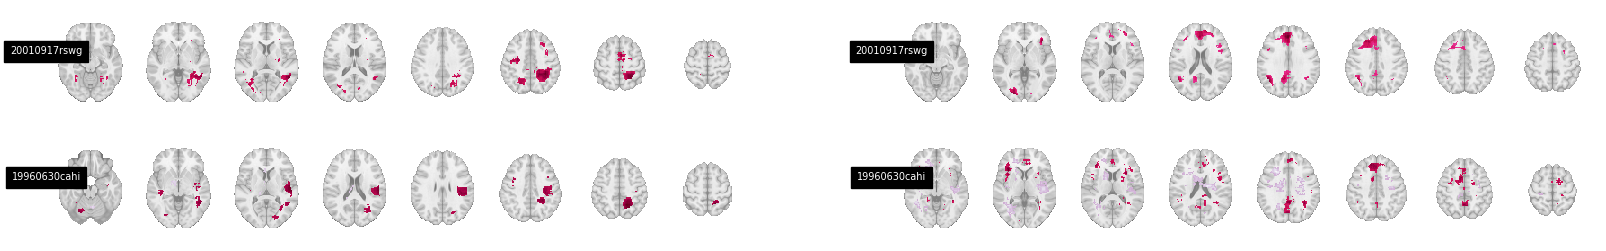

In [ ]:
axes1 = deepcopy(axes)
for row in np.arange(0, axes1.shape[0]):
    for col in np.arange(0, axes1.shape[1]):
       axes1[row, col]
    #    ax = axes[row, col]
       if row == 0:
         #   print("hi")
          axes1[row, col].set_title("fig sdskdhfskjdhfskjdf", loc='')

fig2 = axes1[0,0].figure
fig2

In [76]:
axes1.shape


(2, 2)

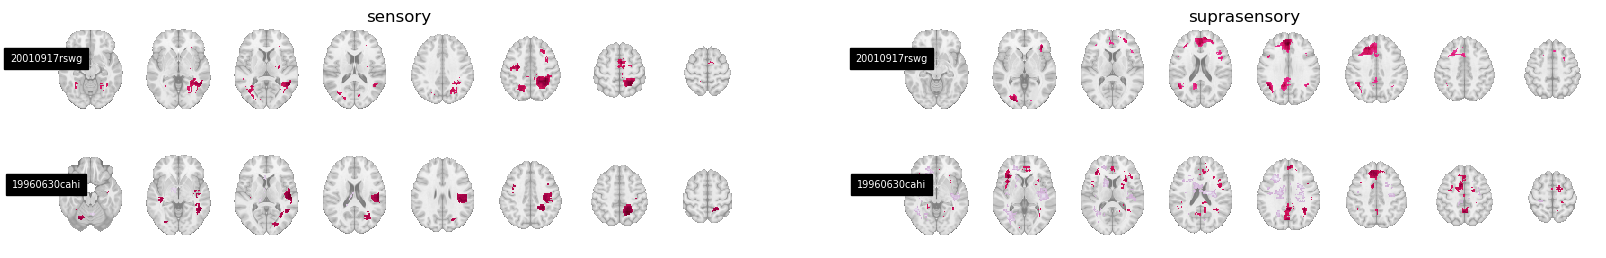

In [66]:
pad=0
axes1 = deepcopy(axes)
for ax, col in zip(axes1[0], ["sensory", "suprasensory"]):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='center')
    # print(dir(ax))
    ax.margins(x=10)
fig2 = axes1[0,0].figure
# fig2.subplots_adjust(top=0.85, right=8)
fig2

## single subject

In [ ]:
# load data
config_class_name = 'SensoryConfig_E4'
thres = 95


all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]
subjectID = all_subjects[0]

RDM_brain_list = []

# for subjectID in all_subjects:

cfg = load_MRI_config_instance(config_class_name, subjectID)
cfg.configure_paths()
outFiles = cfg.get_outFile_names()
RDM_brain = joblib.load(outFiles['RDM_brain_fullBrain'])

mask = nib.load(cfg.get_mask_file())
RDM_brain_nan = copy.deepcopy(RDM_brain)
RDM_brain_nan[RDM_brain_nan == 0] = np.nan
threshold = np.nanpercentile(RDM_brain_nan, thres)

subj_img = new_img_like(mask, RDM_brain)

# easy way to filter data by threshold 
threshold_value_img = threshold_img(
    subj_img, threshold= threshold, copy=True, copy_header=True
)

# binary mask including above average voxels = 1
threshold_mask = np.zeros(threshold_value_img.get_fdata().shape)
threshold_mask[threshold_value_img.get_fdata() > 0] = 1




In [42]:
len('Most of the numerous studies on the conscious perception of sensory information focus on a single sensory modality. We aim to extend the perspective to a framework of supramodal neural correlates of consciousness (NCC). Using a report-based detection paradigm including visual, auditory and tactile near-threshold (NT) stimuli, we combine data from functional magnetic resonance imaging (fMRI) and magnetoencephalography (MEG) using representational similarity analysis. This rigorous methodological approach combines the strengths of both fMRI and MEG, facilitating excellent spatial resolution as well as superior temporal precision. Preliminary results on the temporal dynamics of conscious perception indicate that neural activity reflecting the pure sensory processing of stimuli precedes the activity patterns associated with conscious perception. Whereas stimulus-driven activation was primarily observed in sensory areas contralateral to the stimulated side, activity patterns distinguishing perceived from unperceived stimuli—independent of sensory modality—were found in frontal regions and in parietal areas predominantly ipsilateral to the stimulation. These preliminary findings suggest the involvement of a fronto-parietal network in the transition from modality-specific sensory processing to integrative supramodal conscious perception.')

1352

# all subjects, sum of threshold masks

## 14 subjects

### C2 

Removed bad subject: 19970218crpo

all MRI subjects: ['20010917rswg', '19960630cahi', '19970302urmr', '19840930bigs', '20040627vrrj', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19921205crfi', '19991211mrbn', '19910823ssld', '19910703eigl']


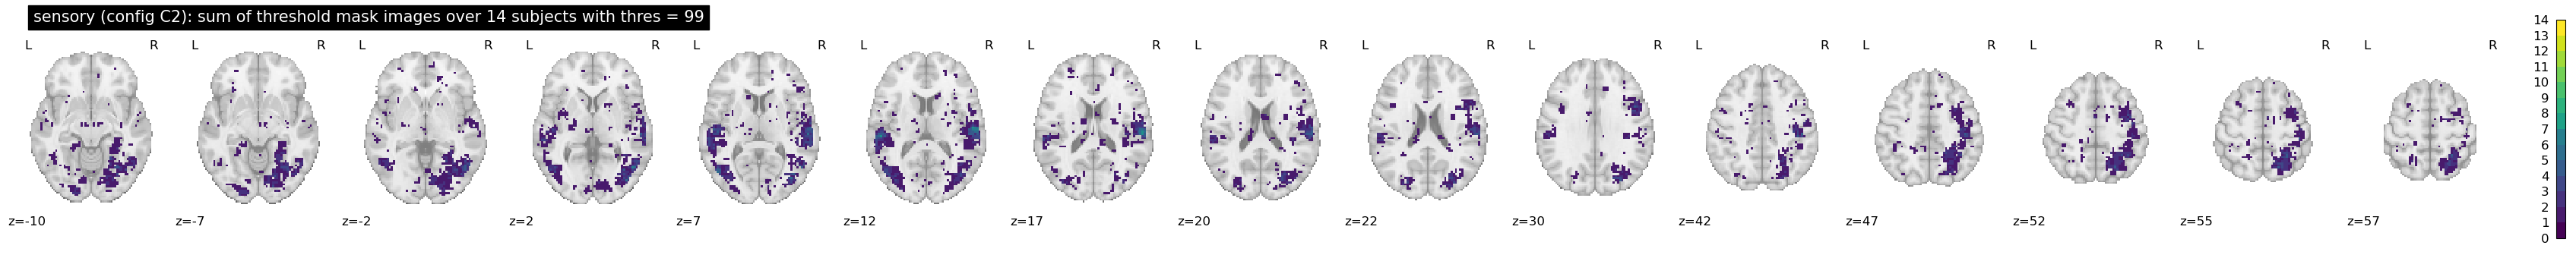

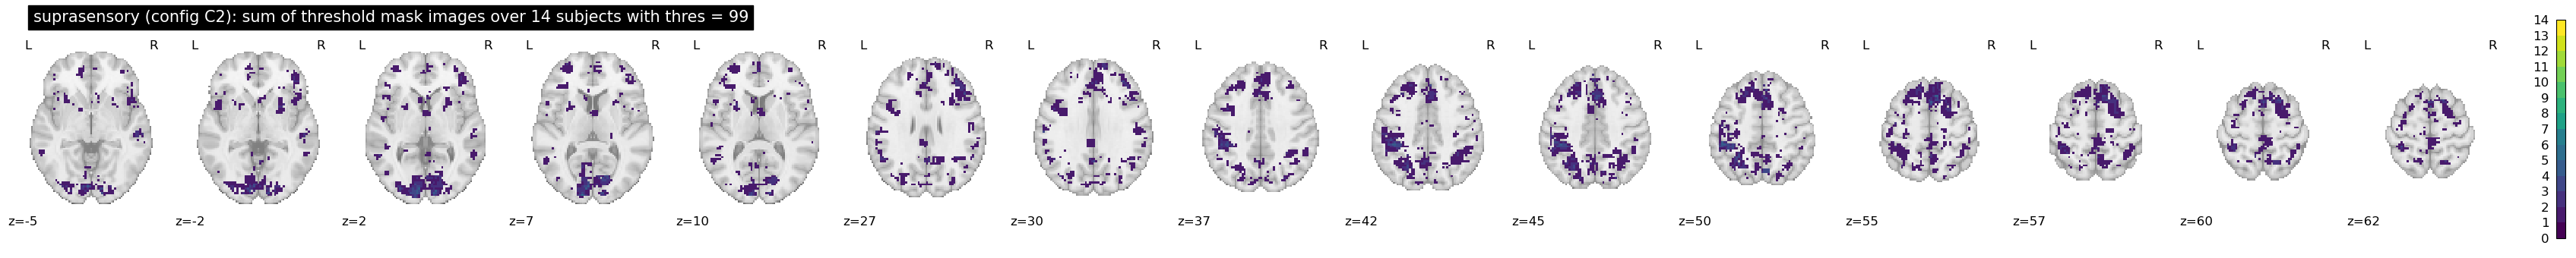

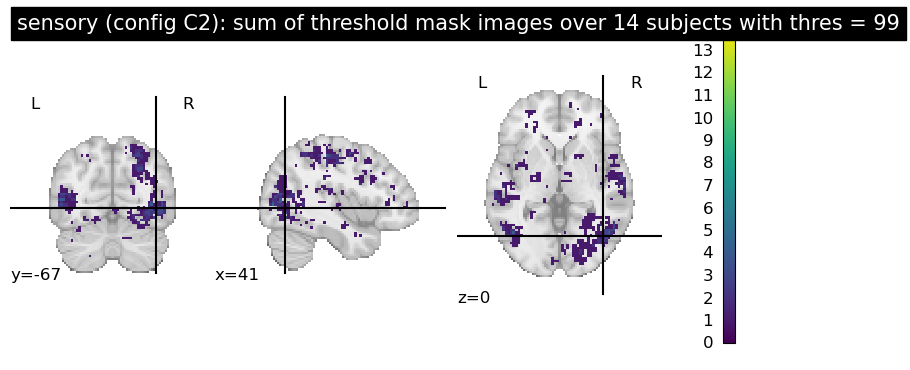

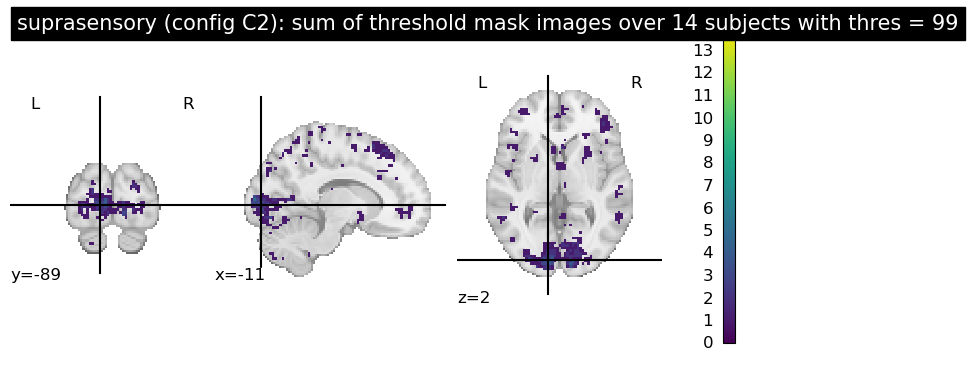

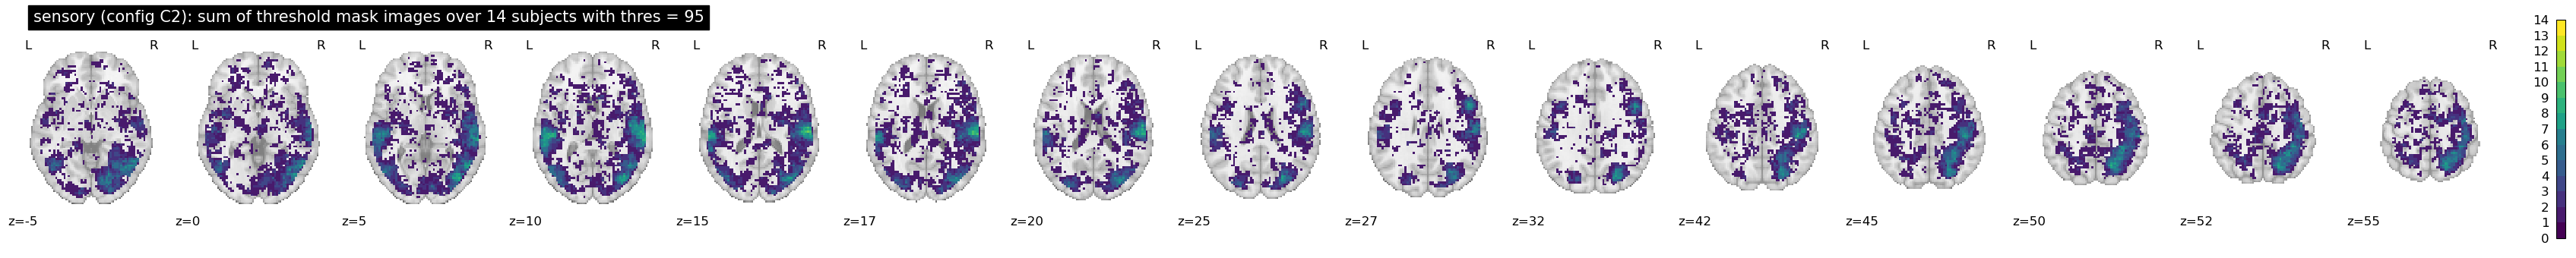

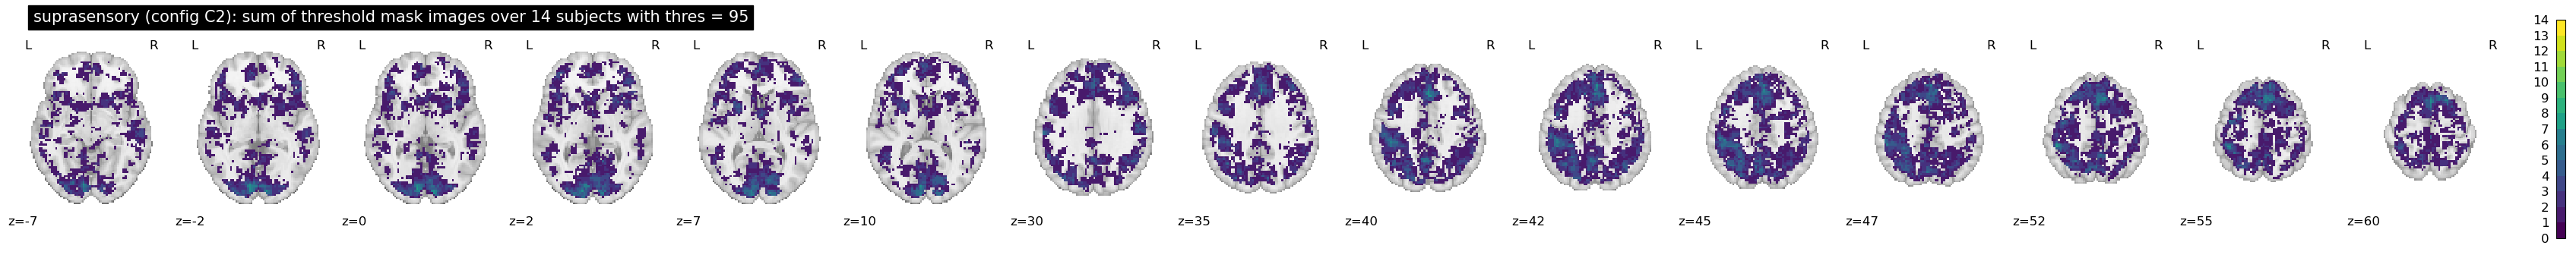

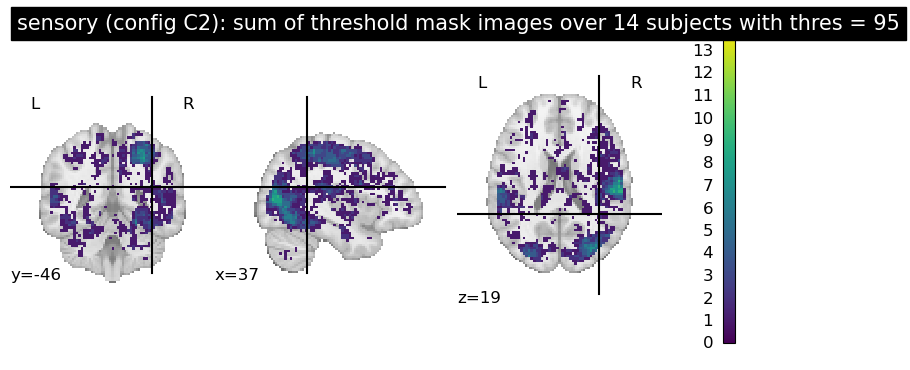

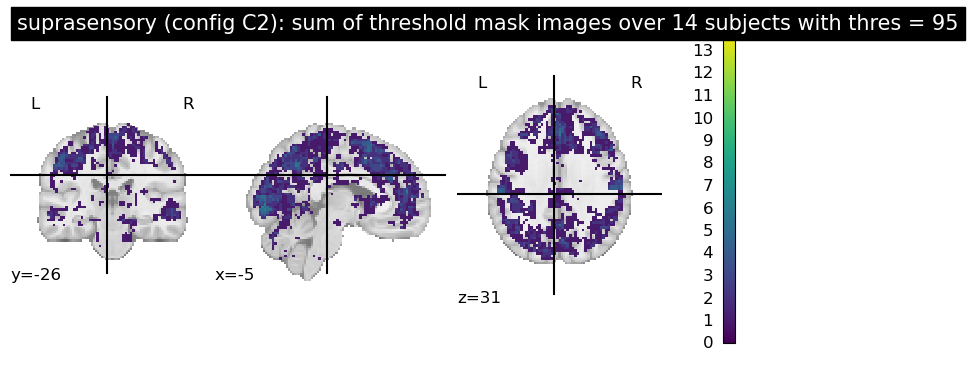

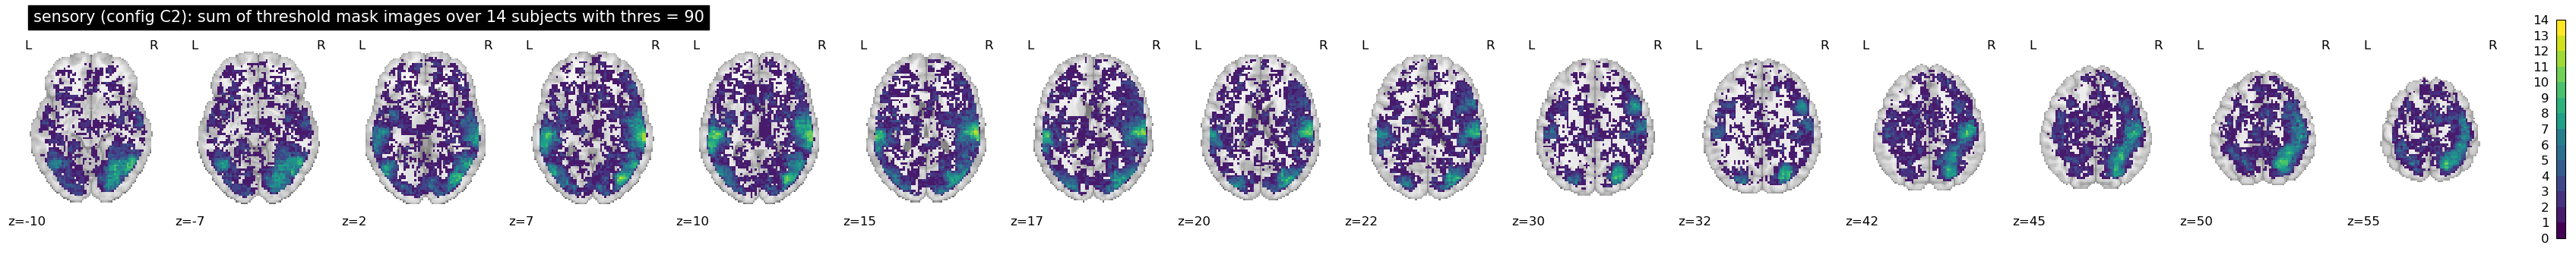

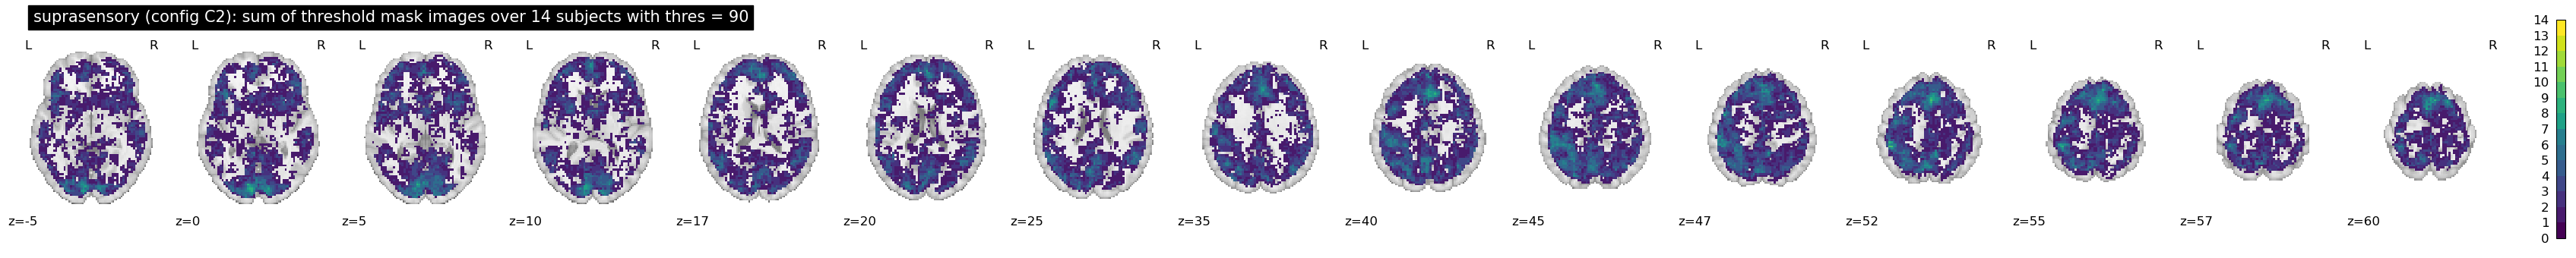

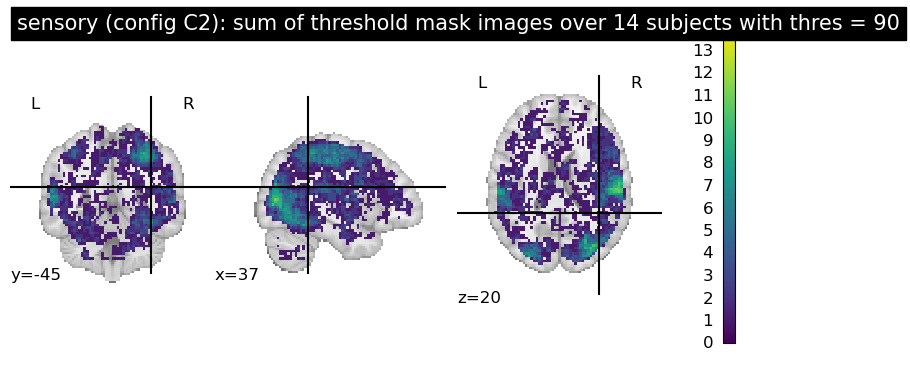

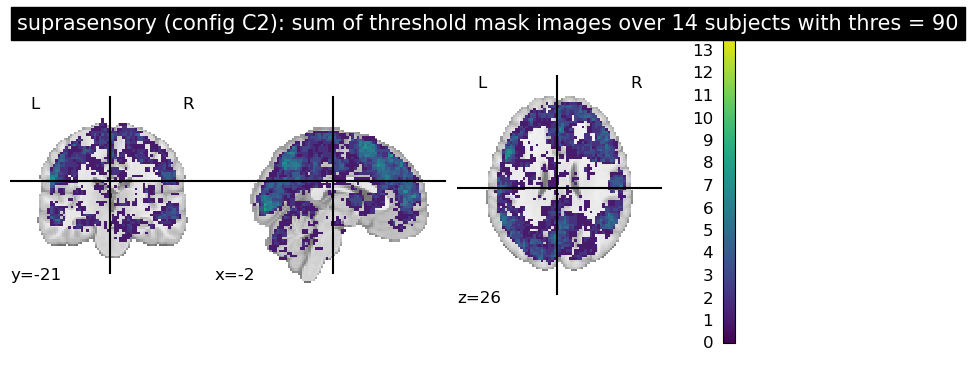

In [41]:
all_subjects = [subj for subj in get_MRI_subjects() if '19970218crpo' not in subj]
this_config = 'MRIconfig_C2'

for thres in [99, 95, 90]:
    plot_accumulated_thres(all_subjects, this_config, 'sensory', thres=thres, save = False)
    plot_accumulated_thres(all_subjects, this_config, 'suprasensory', thres=thres, save = False)
    plot_accumulated_thres(all_subjects, this_config, 'sensory', thres=thres, save = False, plotList=[2])
    plot_accumulated_thres(all_subjects, this_config, 'suprasensory', thres=thres, save = False, plotList=[2])

Removed bad subject: 19970218crpo

all MRI subjects: ['20010917rswg', '19960630cahi', '19970302urmr', '19840930bigs', '20040627vrrj', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19921205crfi', '19991211mrbn', '19910823ssld', '19910703eigl']


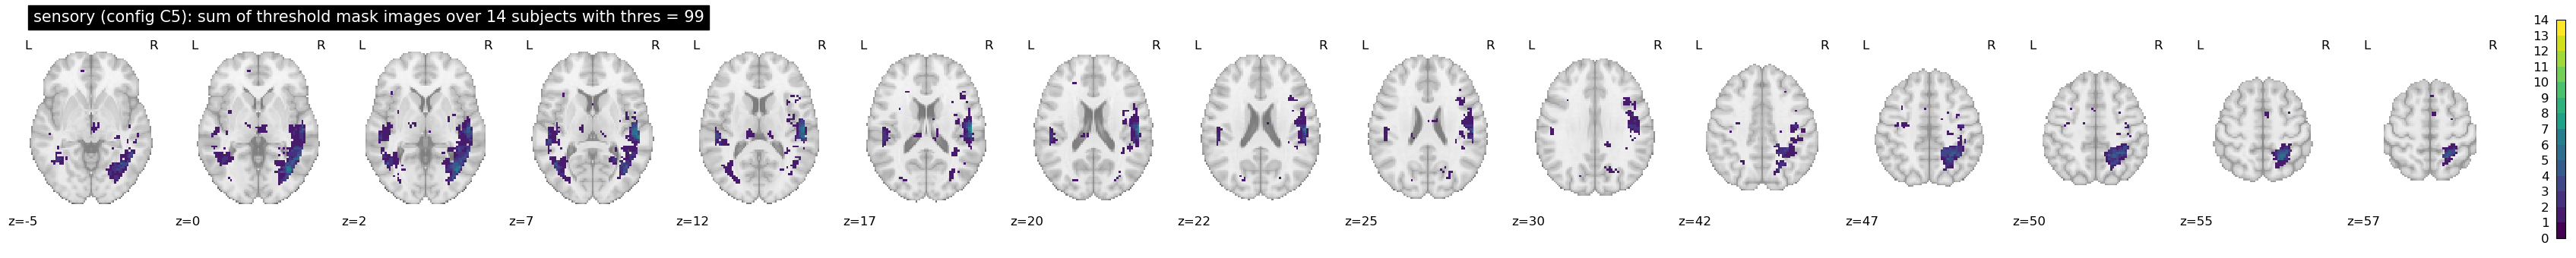

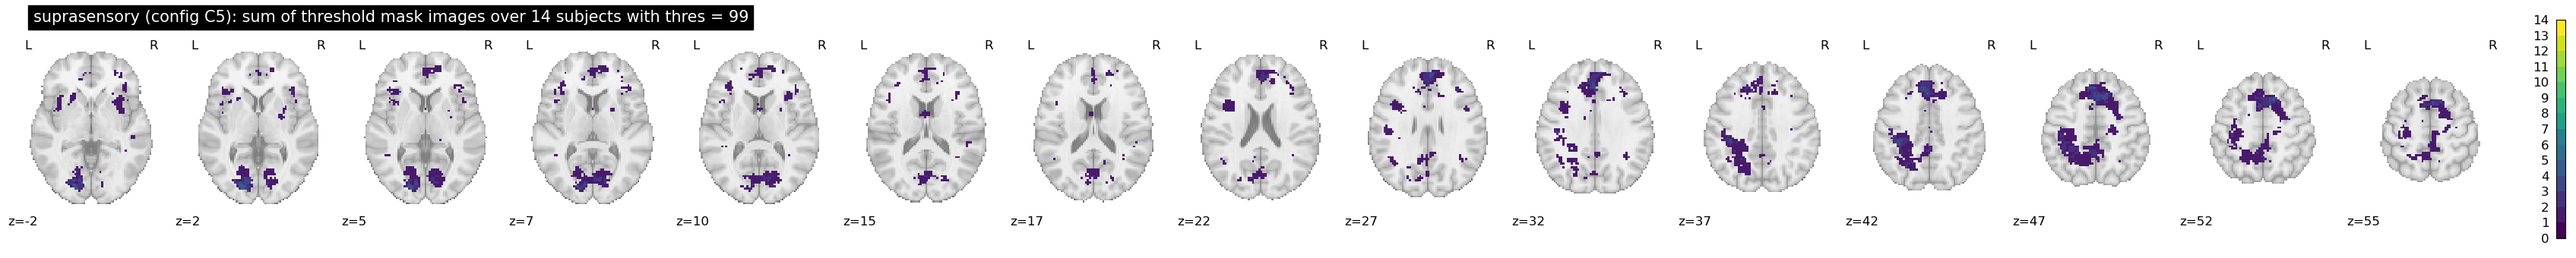

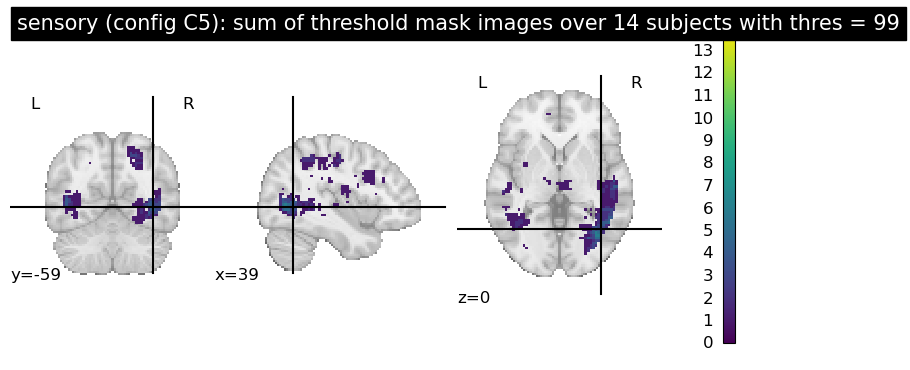

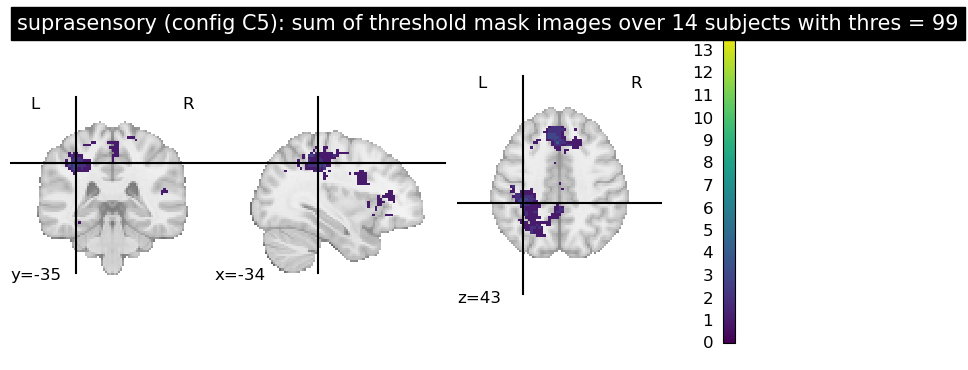

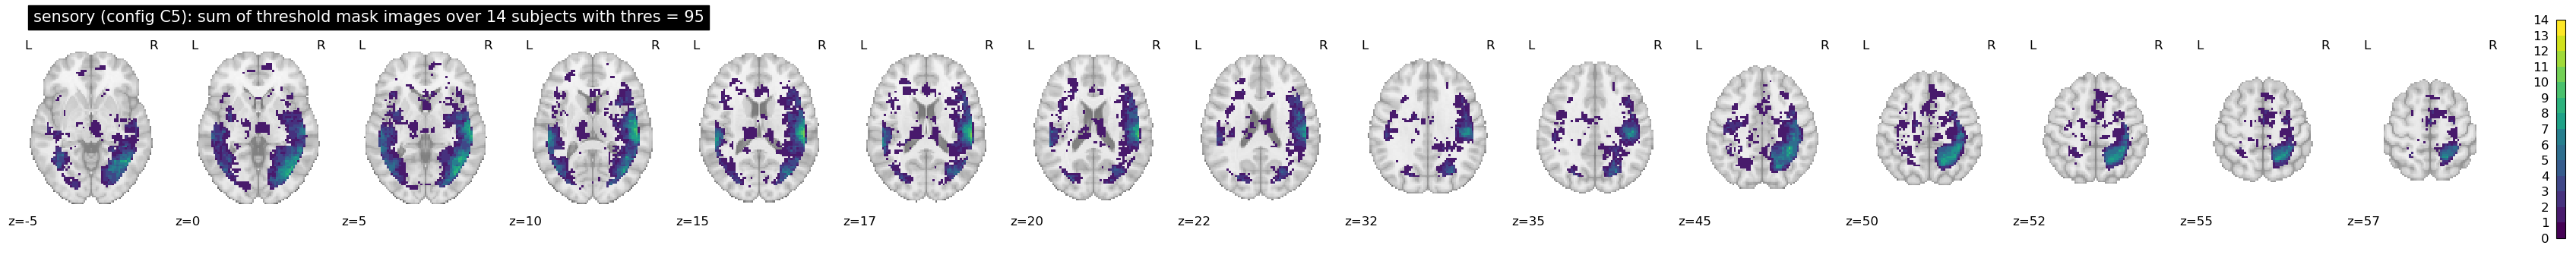

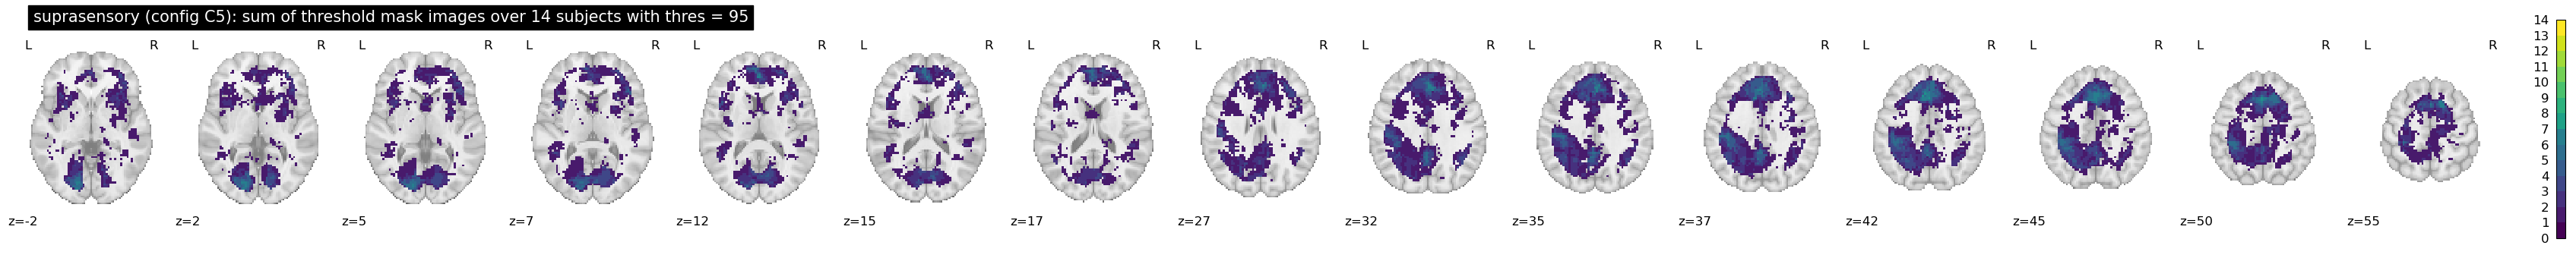

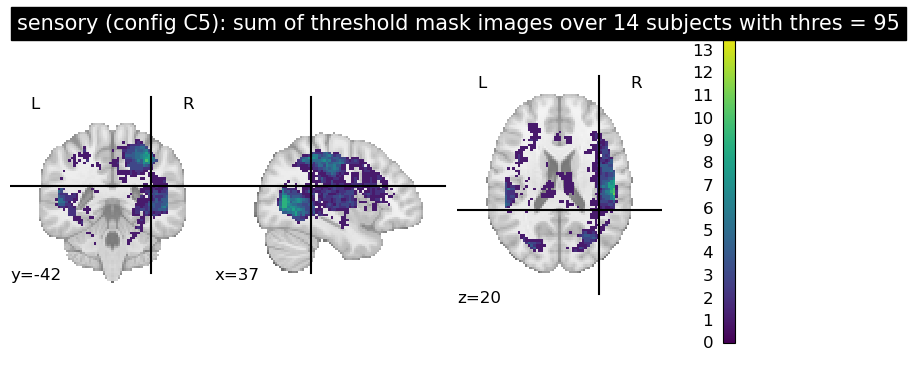

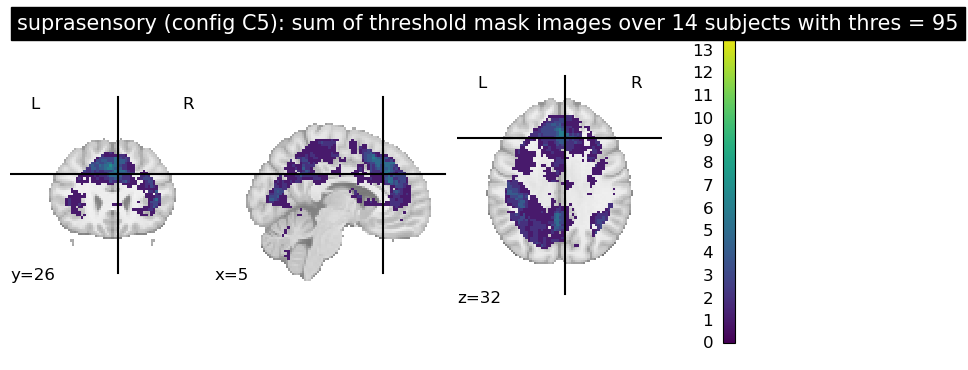

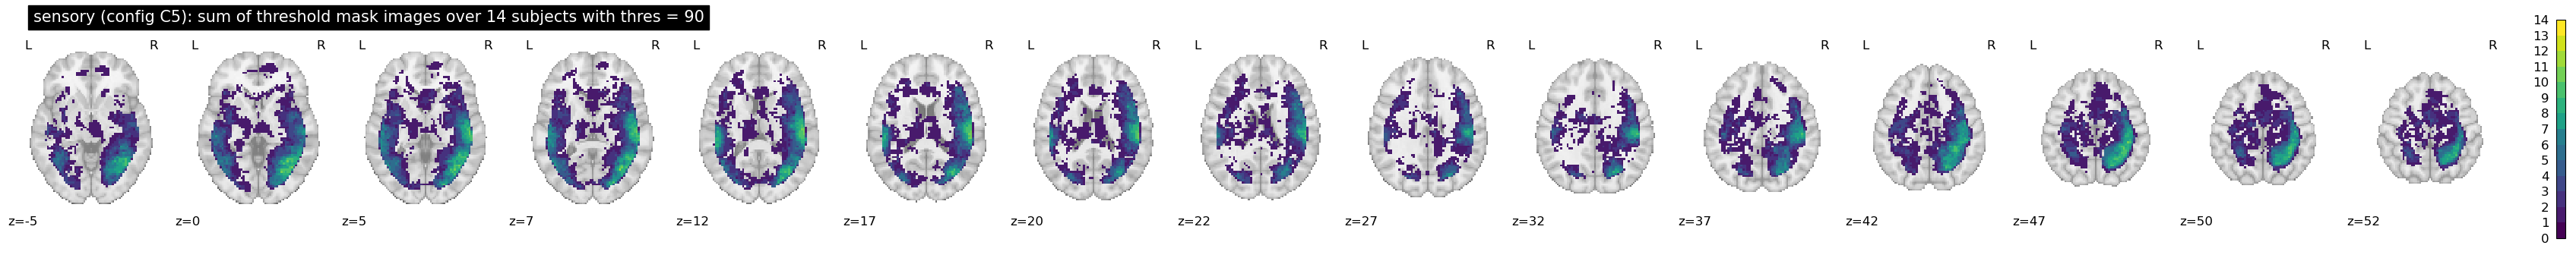

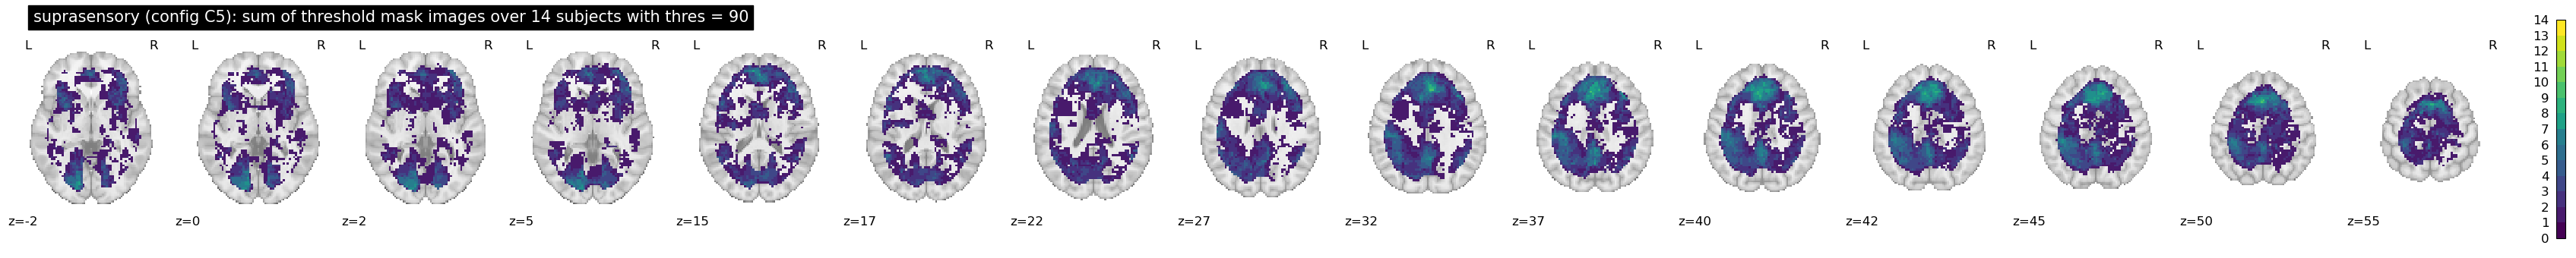

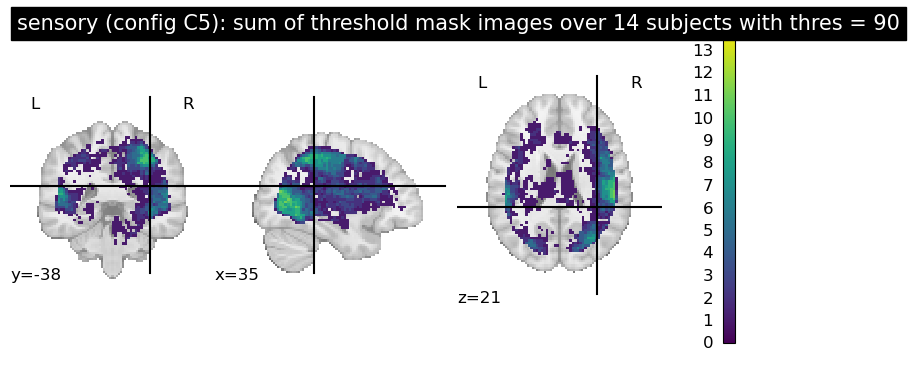

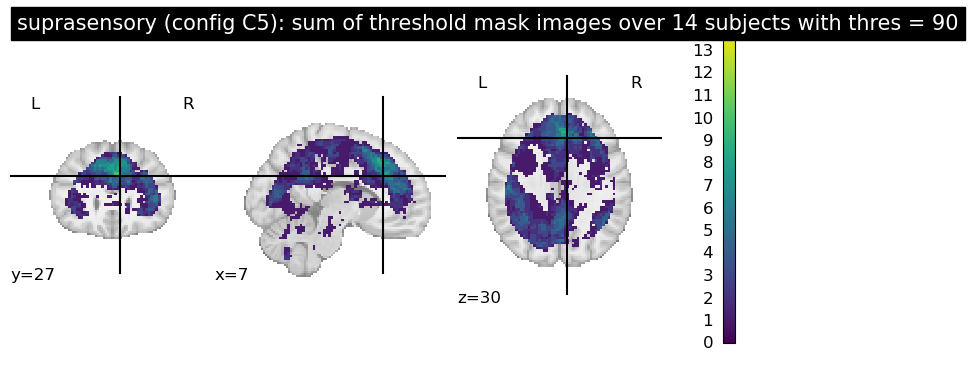

In [42]:
all_subjects = [subj for subj in get_MRI_subjects() if '19970218crpo' not in subj]
this_config = 'MRIconfig_C5'

for thres in [99, 95, 90]:
    plot_accumulated_thres(all_subjects, this_config, 'sensory', thres=thres, save = False)
    plot_accumulated_thres(all_subjects, this_config, 'suprasensory', thres=thres, save = False)
    plot_accumulated_thres(all_subjects, this_config, 'sensory', thres=thres, save = False, plotList=[2])
    plot_accumulated_thres(all_subjects, this_config, 'suprasensory', thres=thres, save = False, plotList=[2])

# Plot the mean

shape of RDM_brain_all_nan: (63, 76, 55, 14)
threshold: 0.28240333703133846


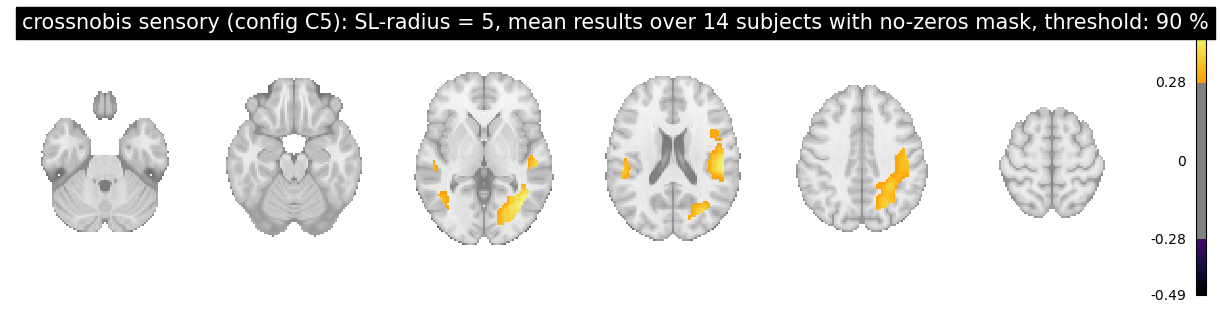

shape of RDM_brain_all_nan: (63, 76, 55, 14)
threshold: 0.08940601275668669


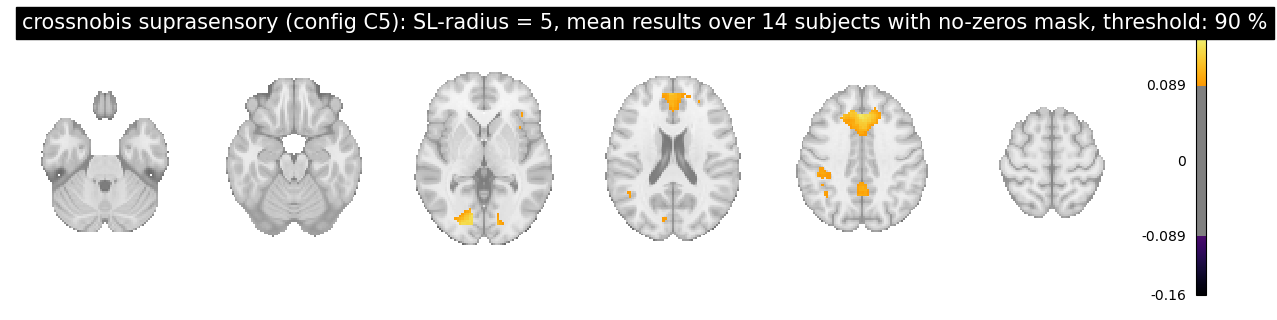

In [ ]:
for thres in [80, 85, 90, 95]:
    plot_mean_results(all_subjects, 'MRIconfig_C5', thres_type = 'percentage', thres= 90, plottype= 2)